In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\Breast_cancer_data.csv")

In [3]:
df=data.copy()

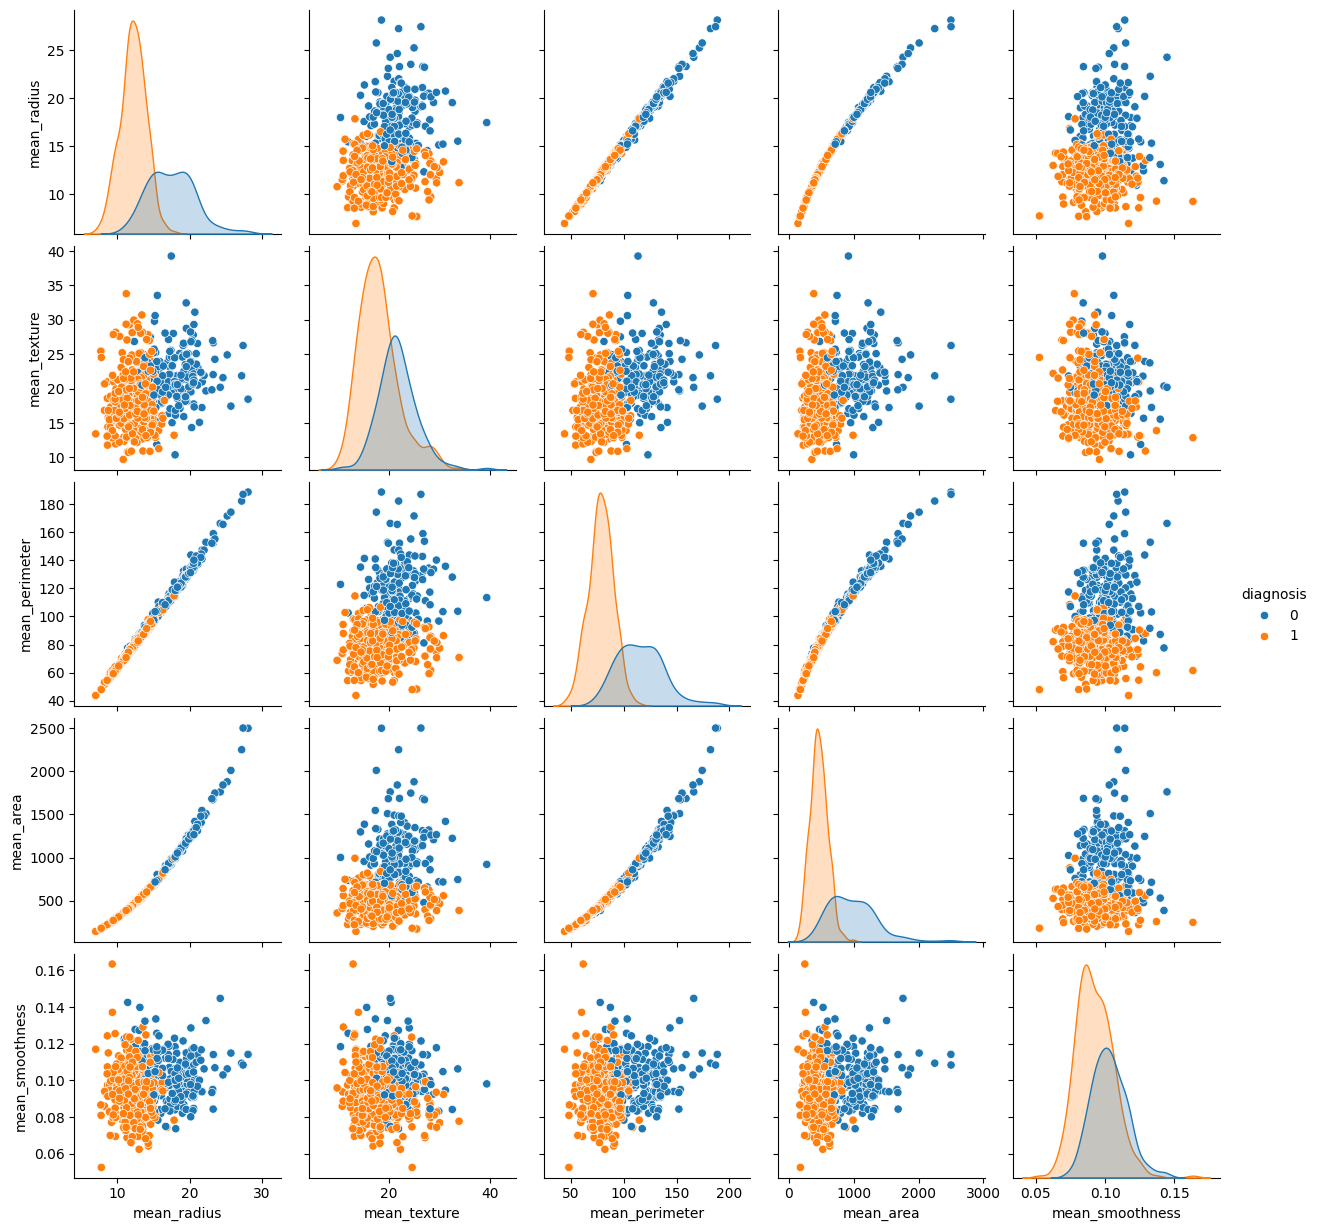

In [6]:
sns.pairplot(data=df,hue="diagnosis")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [10]:
df.head(2)

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.8,1001.0,0.11840,0
1,20.57,17.77,132.9,1326.0,0.08474,0


In [11]:
x=df[["mean_radius","mean_texture","mean_perimeter","mean_area","mean_smoothness"]]
y=df["diagnosis"]

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [25]:
dc=DecisionTreeClassifier(max_depth=7)
dc.fit(x_train,y_train)
dc.score(x_test,y_test),dc.score(x_train,y_train)

(0.9122807017543859, 0.989010989010989)

In [24]:
for i in range(1,21):
    dc1=DecisionTreeClassifier(max_depth=i)
    dc1.fit(x_train,y_train)
    print(dc1.score(x_test,y_test),dc.score(x_train,y_train),i)

0.9210526315789473 0.989010989010989 1
0.9210526315789473 0.989010989010989 2
0.9035087719298246 0.989010989010989 3
0.9122807017543859 0.989010989010989 4
0.9298245614035088 0.989010989010989 5
0.9298245614035088 0.989010989010989 6
0.9122807017543859 0.989010989010989 7
0.9035087719298246 0.989010989010989 8
0.9122807017543859 0.989010989010989 9
0.9035087719298246 0.989010989010989 10
0.9122807017543859 0.989010989010989 11
0.9122807017543859 0.989010989010989 12
0.9122807017543859 0.989010989010989 13
0.9035087719298246 0.989010989010989 14
0.9122807017543859 0.989010989010989 15
0.9035087719298246 0.989010989010989 16
0.9035087719298246 0.989010989010989 17
0.9122807017543859 0.989010989010989 18
0.9122807017543859 0.989010989010989 19
0.8947368421052632 0.989010989010989 20


In [26]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()
lg.fit(x_train,y_train)
lg.score(x_test,y_test)

0.9298245614035088

In [27]:
from sklearn.naive_bayes import GaussianNB,BernoulliNB

In [28]:
gs=GaussianNB()
gs.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [29]:
gs.score(x_test,y_test)

0.9385964912280702

In [34]:
from mlxtend.feature_selection import SequentialFeatureSelector

In [69]:
se=SequentialFeatureSelector(estimator=lg,forward=True,k_features=5)
se.fit(x,y)

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sciki

,estimator,LogisticRegression()
,k_features,"(5, ...)"
,forward,True
,floating,False
,verbose,0
,scoring,'accuracy'
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [70]:
print(se.k_feature_names_,se.k_score_)

('mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness') 0.9068622884645242


In [71]:
from mlxtend.plotting import plot_decision_regions

In [72]:
#plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=gs)
plt.show()

In [74]:
from sklearn.svm import SVC
svc=SVC(kernel='linear')
svc.fit(x_train,y_train)
svc.score(x_test,y_test)

0.9385964912280702

In [84]:
list=[("lg1",LogisticRegression()),("scm1",SVC()),("gs1",GaussianNB())]

In [85]:
from sklearn.ensemble import VotingClassifier

In [86]:
vt=VotingClassifier(estimators=list)

In [87]:
vt.fit(x_train,y_train)

,estimators,"[('lg1', ...), ('scm1', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [88]:
vt.score(x_test,y_test)


0.9385964912280702

In [91]:
list1={"lg":lg.predict(x_test),"svm1":svc.predict(x_test),"gs":gs.predict(x_test),"vottong":vt.predict(x_test),"real":y_test}

In [93]:
dff=pd.DataFrame(list1)

In [95]:
dff.head(30)

,lg,svm1,gs,vottong,real
204,1,1,1,1,1
70,0,0,0,0,0
131,0,0,0,0,0
431,1,1,1,1,1
540,1,1,1,1,1
567,0,0,0,0,0
369,0,0,0,0,0
29,0,0,0,0,0
81,1,1,1,1,1
477,1,1,1,1,1
